Artists that map data to color pass the arguments vmin and vmax to construct a matplotlib.colors.Normalize() instance, then call it:

However, there are sometimes cases where it is useful to map data to colormaps in a non-linear fashion.

<h2>Logarithmic</h2>
One of the most common transformations is to plot data by taking its logarithm (to the base-10). This transformation is useful to display changes across disparate scales. Using colors.LogNorm normalizes the data via 𝑙⁢𝑜⁢𝑔10. In the example below, there are two bumps, one much smaller than the other. Using colors.LogNorm, the shape and location of each bump can clearly be seen:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.cbook as cbook
import matplotlib.colors as colors

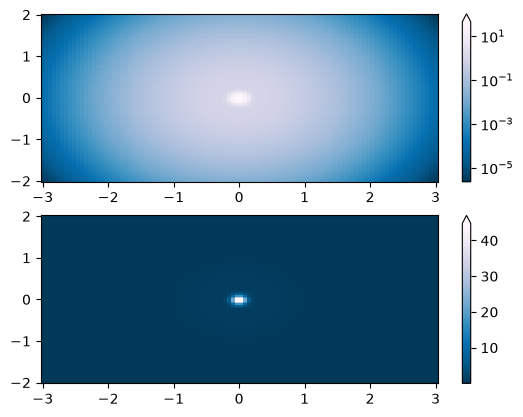

In [6]:
N = 100
X, Y = np.mgrid[-3:3:complex(0, N), -2:2:complex(0,N)]
# A low hump with a spike coming out of the top right.  Needs to have
# z/colour axis on a log scale, so we see both hump and spike. A linear
# scale only shows the spike.
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X * 10)**2 - (Y * 10)**2)
Z = Z1 +50 * Z2

fig, ax = plt.subplots(2, 1)

pcm = ax[0].pcolor(X, Y, Z,
                  norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max()),
                  cmap='PuBu_r', shading='auto')
fig.colorbar(pcm, ax=ax[0], extend='max')

pcm = ax[1].pcolor(X,Y,Z,cmap='PuBu_r', shading='auto')
fig.colorbar(pcm, ax=ax[1], extend='max')
plt.show()
                   